Epoch: 0 Loss: 56.136612492472366
Epoch: 1 Loss: 38.074064166818154
Epoch: 2 Loss: 31.35352183020614
Epoch: 3 Loss: 28.456968589789398
Epoch: 4 Loss: 40.09914864671419
Epoch: 5 Loss: 556.141682854643
Epoch: 6 Loss: 22.308619429121542
Epoch: 7 Loss: 22.360226974395538
Epoch: 8 Loss: 21.86154802598621
Epoch: 9 Loss: 20.3451658120627
Epoch: 10 Loss: 17.651718991827664
Epoch: 11 Loss: 17.604756226657223
Epoch: 12 Loss: 17.197921267815165
Epoch: 13 Loss: 17.55248761824595
Epoch: 14 Loss: 15.33333138388744
Epoch: 15 Loss: 16.802554210580535
Epoch: 16 Loss: 14.505620190881404
Epoch: 17 Loss: 17.2456005592596
Epoch: 18 Loss: 15.59301312757877
Epoch: 19 Loss: 14.873406332173552
Epoch: 20 Loss: 16.52313415206502
Epoch: 21 Loss: 14.183328727925073
Epoch: 22 Loss: 12.84480554666705
Epoch: 23 Loss: 13.314090099368421
Epoch: 24 Loss: 12.405504321877816
Epoch: 25 Loss: 12.237076625668482
Epoch: 26 Loss: 160430.7767718002
Epoch: 27 Loss: 19.93807550896521
Epoch: 28 Loss: 15.812463831891284
Epoch: 29 L

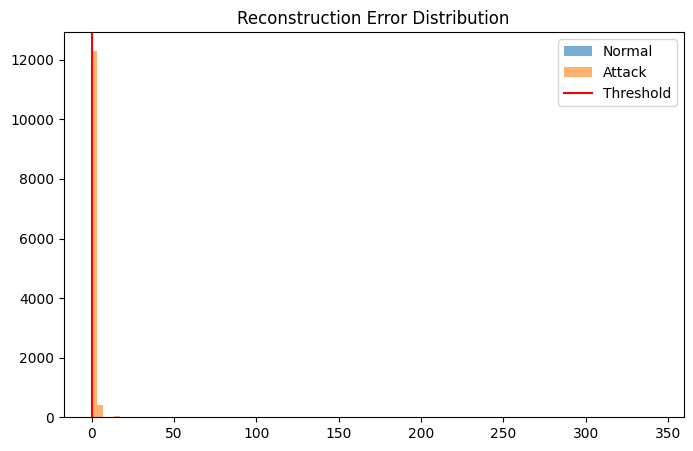

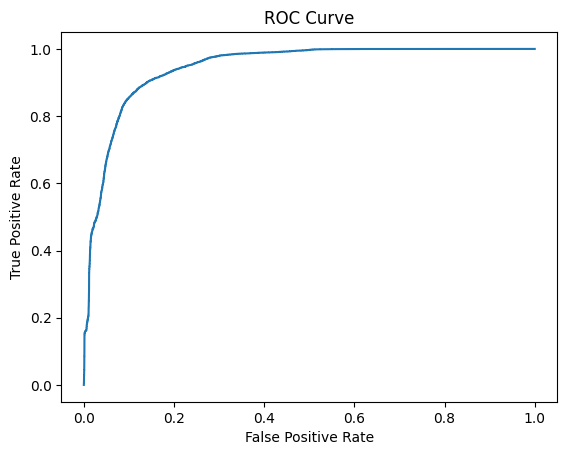

In [ ]:
# ================================
# VAE Anomaly Detection - NSL-KDD
# ================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# 1 DATASET LOAD
# ================================

columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
"urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
"num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
"is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
"rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
"dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df = pd.read_csv("KDDTest+.txt", names=columns)

train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

# ================================
# 2 LABEL BINARY
# ================================

train_df["label"] = train_df["label"].apply(lambda x: 0 if x=="normal" else 1)
test_df["label"] = test_df["label"].apply(lambda x: 0 if x=="normal" else 1)

# ================================
# 3 ONE HOT ENCODING
# ================================

combined = pd.concat([train_df, test_df])

combined = pd.get_dummies(combined, columns=["protocol_type","service","flag"])

train_df = combined.iloc[:len(train_df)]
test_df = combined.iloc[len(train_df):]

# ================================
# 4 FEATURE / LABEL
# ================================

X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

# ================================
# 5 SCALE
# ================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 6 ONLY NORMAL FOR TRAIN
# ================================

X_train_normal = X_train[y_train == 0]

# ================================
# 7 DATA LOADER
# ================================

batch_size = 256

train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=batch_size,
    shuffle=True
)

# ================================
# 8 VAE MODEL
# ================================

input_dim = X_train.shape[1]
latent_dim = 16

class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,input_dim)
        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu,logvar)

        recon = self.decoder(z)

        return recon, mu, logvar

model = VAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ================================
# 9 LOSS FUNCTION
# ================================

def loss_function(recon_x, x, mu, logvar):

    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')

    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kld

# ================================
# 10 TRAIN
# ================================

epochs = 50

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss = loss_function(recon,x,mu,logvar)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader.dataset))

# ================================
# 11 RECONSTRUCTION ERROR
# ================================

def reconstruction_errors(data):

    model.eval()

    data = torch.tensor(data,dtype=torch.float32).to(device)

    with torch.no_grad():

        recon,_,_ = model(data)

        mse = torch.mean((data-recon)**2,dim=1)

    return mse.cpu().numpy()

train_errors = reconstruction_errors(X_train_normal)

test_errors = reconstruction_errors(X_test)

# ================================
# 12 THRESHOLD
# ================================

threshold = np.percentile(train_errors,95)

print("Threshold:",threshold)

# ================================
# 13 PREDICTION
# ================================

y_pred = (test_errors > threshold).astype(int)

# ================================
# 14 METRICS
# ================================

roc_auc = roc_auc_score(y_test, test_errors)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp/(fp+tn)

print("\n===== RESULTS =====")

print("ROC AUC:",roc_auc)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("False Positive Rate:",fpr)

# ================================
# 15 RECONSTRUCTION ERROR PLOT
# ================================

normal_errors = test_errors[y_test==0]
attack_errors = test_errors[y_test==1]

plt.figure(figsize=(8,5))

plt.hist(normal_errors, bins=100, alpha=0.6, label="Normal")
plt.hist(attack_errors, bins=100, alpha=0.6, label="Attack")

plt.axvline(threshold,color="red",label="Threshold")

plt.legend()

plt.title("Reconstruction Error Distribution")

plt.show()

# ================================
# 16 ROC CURVE
# ================================

fpr_vals,tpr_vals,_ = roc_curve(y_test,test_errors)

plt.plot(fpr_vals,tpr_vals)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()